<a href="https://colab.research.google.com/github/MauAlcantara1/Keras-y-Tensorflow/blob/main/Introduccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y jax jaxlib tensorflow numpy ml_dtypes
!pip install numpy==1.26.4
!pip install ml_dtypes==0.5.1
!pip install tensorflow==2.17.0

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras 3.13.2 requires ml-dtypes, which is not installed.
optax 0.2.8 requires jax>=0.5.3, which is not installed.
optax 0.2.8 requires jaxlib>=0.5.3, which is not installed.
orbax-checkpoint 0.11.36 requires jax>=0.6.0, which is not installed.
tensorstore 0.1.82 requires ml_dtypes>=0.5.0, which is not installed.
flax 0.11.2 requires jax>=0.6.0, which is not installed.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
dopamine-rl 4.1

  Using cached ml_dtypes-0.5.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (21 kB)
Using cached ml_dtypes-0.5.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.11.2 requires jax>=0.6.0, which is not installed.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
  Using cached tensorflow-2.17.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.4/601.4 MB 751.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.0 MB/s 

In [1]:

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')

En el codigo pasado solo importamos lo que usaremos para generar el modelo funcional de la API.

Importamos model para crear modelos de la API funcional de keras

Importamos las capas input y dense que se usara para la red

La ultima solo importamos los warnings y se oculta los warnings innecesarios



In [3]:
# Definimos la capa de entrada del modelo
# shape=(20,) indica que cada dato de entrada tendrá 20 características
input_layer = Input(shape=(20,))

# Mostramos la representación de la capa de entrada creada
print(input_layer)

<KerasTensor shape=(None, 20), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>


# Salida:
# <KerasTensor shape=(None, 20), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

None representa el tamaño del lote (batch size), el cual puede variar.
20 indica que cada muestra de entrada contiene 20 variables o características.
float32 es el tipo de dato que utilizará TensorFlow para procesar la información.

In [4]:
# Creamos la primera capa oculta con 64 neuronas y función de activación ReLU
# Esta capa recibe como entrada la capa de entrada definida anteriormente
hidden_layer1 = Dense(64, activation='relu')(input_layer)

# Creamos la segunda capa oculta con 64 neuronas y activación ReLU
# Esta capa utiliza como entrada la salida de la primera capa oculta
hidden_layer2 = Dense(64, activation='relu')(hidden_layer1)

Dense(64, activation='relu') crea una capa completamente conectada (fully connected) con 64 neuronas.
La función de activación relu ayuda al modelo a aprender patrones no lineales y es una de las más utilizadas en redes neuronales.
Cada capa oculta recibe como entrada la salida de la capa anterior, formando el flujo de información dentro de la red neuronal.

Aqui voy a ser preciso, una neurona en IA intenta simular lo a una reurona real, recibe informacion, hace calculos, decie que tanto hacer "su funcion"


Imagina esto

Supón que quieres predecir si un estudiante aprobará un examen.

Las entradas podrían ser:

Horas de estudio
Horas de sueño
Asistencia
Tareas entregadas

La neurona recibe esos valores y hace algo parecido a:

resultado=(x1w1)+(x2w2)+(x3w3)+b
y=x1​w1​+x2w2+x3w3+b

Donde:

x = datos de entrada

w = pesos (qué tan importante es cada dato)

b = sesgo (bias)

y = resultado antes de activarse

Aqui entran dos conceptos importantes, pesos y el sesgo, las cuales explicare en un momento.

Cada neurona aprendera patrones diferentes automaticamente pero otra cosa importante es la parte de la funcion de activacion, despues del calculo la neurona piensa "Esta informacion resulta importante?"
Sin las funciones de activacion la red seria solo una calculadora lineal gigante

La más usada es la ReLU

f(x) = man(0,x)

Solo dice que si el valor es negativo devuelve 0 pero si es positivo lo deja pasar

ReLU permite ignorar informacion poco util, aprender patrones complejos y entrena mas rapido

Los pesos nos ayudan a calcular que tan importante es cada entrada

años de experiencia

nivel de estudios

en el ejemplo a simple vista podemos decir que los años de experiencia tienen más impacto en el salario

El bias es un ajuste extra, ayuda a mover el resultato arriba o abajo

La IA aprendera ajustando esos patrones hasta que las predicciones se parezcan a las respuestas

Fallara pero cada vez se acercara más

¿Cómo aprende la red?

Usa:

**Forward Propagation:**

Hace predicciones.

Luego:

**Loss Function**

Mide el error.

Ejemplo:

error=prediccion−valor real

Después:

**Backpropagation**

Calcula cómo cambiar pesos y bias para reducir el error.

Al final realiza:

**Gradient Descent**

El optimizador modifica los parámetros poquito a poquito:

nuevo peso=peso−learning rate×gradiente

nuevo peso=peso−learning rate×gradiente

Eso ocurre miles o millones de veces.

In [6]:
# Definimos la capa de salida del modelo
# Dense(1) indica que la salida tendrá una sola neurona
# activation='sigmoid' transforma el resultado en un valor entre 0 y 1

output_layer = Dense(1, activation='sigmoid')(hidden_layer2)

La capa de salida se encarga de generar la prediccion final del modelo, la funcion sigmoid convierte el resultado en una probabilidad entre 1 y 0

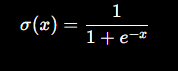

Esto permite que el modelo entregue valores interpetables como probabilidades

In [7]:
# Creamos el modelo funcional conectando la capa de entrada
# con la capa de salida a través de las capas ocultas

model = Model(inputs=input_layer, outputs=output_layer)

# Mostramos un resumen completo de la arquitectura del modelo
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compilamos el modelo definiendo:
# - El optimizador
# - La función de pérdida
# - La métrica de evaluación

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Aqui se compila todo el modelo encargado de ajustar los pesos y bias, lo que mencionamos antes, Adam es uno de los mas usados pues aprende rapido, es eficiente, funciona bien generalmente

Adam actualiza los parametros usando gradiente:

nuevo peso=peso−learning rate×gradiente

    loss='binary_crossentropy',

Esta mide que tan equivocada esta la red neuronal
0 -> una clase
1 -> otra clase

Compára la predicion con la respuesta correcta, si el error es grande pues ajusta sus pesos y el bias


    metrics=['accuracy']

Solo mide el porcentaje de predicciones correctas

In [10]:
# Importamos NumPy para generar datos de ejemplo
import numpy as np

# Generamos datos aleatorios de entrenamiento
# 1000 muestras con 20 características cada una
X_train = np.random.rand(1000, 20)

# Generamos etiquetas binarias aleatorias (0 o 1)
# Estas representan las respuestas correctas esperadas
y_train = np.random.randint(2, size=(1000, 1))

# Entrenamos el modelo
# epochs=10 indica cuántas veces recorrerá todo el dataset
# batch_size=32 indica cuántas muestras procesará por grupo

model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4950 - loss: 0.6966
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5110 - loss: 0.6921 
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5440 - loss: 0.6881 
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5470 - loss: 0.6867 
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5470 - loss: 0.6857 
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5580 - loss: 0.6841 
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5480 - loss: 0.6829 
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5890 - loss: 0.6774 
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5840 - loss: 0.6800 
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5900 - loss: 0.6751 


"""
EXPLICACIÓN DEL ENTRENAMIENTO DEL MODELO
---------------------------------------

En este ejemplo se generan datos aleatorios únicamente con fines demostrativos.

En un proyecto real:

- X_train contendría los datos reales de entrada.
- y_train contendría las etiquetas o respuestas correctas.

--------------------------------------------------
DATOS DE ENTRENAMIENTO
--------------------------------------------------

X_train = np.random.rand(1000, 20)

Esto crea:

- 1000 muestras
- cada una con 20 características

Por ejemplo, una fila podría representar información como:

edad, salario, experiencia, horas de estudio, etc.

--------------------------------------------------
ETIQUETAS
--------------------------------------------------

y_train = np.random.randint(2, size=(1000, 1))

Genera valores binarios:

0 o 1

que representan clases diferentes.

Ejemplo:

0 = No
1 = Sí

--------------------------------------------------
ENTRENAMIENTO DEL MODELO
--------------------------------------------------

model.fit(X_train, y_train, epochs=10, batch_size=32)

La función fit() inicia el proceso de aprendizaje
de la red neuronal.

--------------------------------------------------
¿QUÉ ES UN EPOCH?
--------------------------------------------------

epochs=10

Un epoch significa:

Recorrer TODO el dataset una vez completa.

Si existen 1000 muestras y epochs=10:

- el modelo verá el dataset completo 10 veces
- en cada recorrido intentará mejorar sus predicciones

En cada epoch ocurre:

1. El modelo realiza predicciones
2. Calcula el error
3. Ajusta pesos y bias
4. Mejora poco a poco

--------------------------------------------------
¿QUÉ ES BATCH_SIZE?
--------------------------------------------------

batch_size=32

El batch size indica cuántos datos procesa
el modelo antes de actualizar los pesos.

En este caso:

- procesa 32 muestras
- calcula el error
- actualiza pesos y bias
- continúa con las siguientes 32 muestras

Esto ayuda a que el entrenamiento sea más eficiente.

--------------------------------------------------
FLUJO INTERNO DEL ENTRENAMIENTO
--------------------------------------------------

Entrada de datos
        ↓
Predicción
        ↓
Cálculo del error
        ↓
Backpropagation
        ↓
Actualización de pesos y bias
        ↓
Nueva iteración

--------------------------------------------------
¿QUÉ MUESTRA TENSORFLOW DURANTE EL ENTRENAMIENTO?
--------------------------------------------------

Ejemplo:

Epoch 1/10
loss: 0.69 - accuracy: 0.51

Donde:

- loss:
  mide qué tan equivocada está la red neuronal.

- accuracy:
  mide el porcentaje de predicciones correctas.

El objetivo del entrenamiento es:

- disminuir el loss
- aumentar el accuracy

"""

In [11]:
"""
IMPLEMENTACIÓN DE DROPOUT EN UNA RED NEURONAL
==================================================
"""

from tensorflow.keras.layers import Dropout, Dense, Input
from tensorflow.keras.models import Model

# Definimos la capa de entrada
# shape=(20,) indica que cada muestra tiene 20 características
input_layer = Input(shape=(20,))

# Primera capa oculta con 64 neuronas y activación ReLU
hidden_layer = Dense(64, activation='relu')(input_layer)

# Capa Dropout
# rate=0.5 significa que el 50% de las neuronas
# serán desactivadas aleatoriamente durante entrenamiento
dropout_layer = Dropout(rate=0.5)(hidden_layer)

# Segunda capa oculta después de Dropout
hidden_layer2 = Dense(64, activation='relu')(dropout_layer)

# Capa de salida para clasificación binaria
output_layer = Dense(1, activation='sigmoid')(hidden_layer2)

# Creamos el modelo funcional
model = Model(inputs=input_layer, outputs=output_layer)

# Mostramos la arquitectura completa del modelo
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

CAPA DROPOUT


Dropout es una técnica utilizada para reducir
el overfitting en redes neuronales.


¿CÓMO FUNCIONA?


Durante el entrenamiento:

- algunas neuronas se desactivan aleatoriamente
- sus salidas se vuelven temporalmente cero

En este ejemplo:

Dropout(rate=0.5)

significa que:

- el 50% de las neuronas serán apagadas temporalmente
  en cada iteración del entrenamiento.


¿POR QUÉ ES IMPORTANTE?


Dropout ayuda a evitar que el modelo:

- memorice los datos de entrenamiento
- dependa demasiado de neuronas específicas

Esto obliga a la red neuronal a:

- aprender patrones más generales
- mejorar su capacidad de generalización


PUNTO IMPORTANTE


La capa Dropout SOLO funciona durante el entrenamiento.

Durante evaluación o predicción:

- todas las neuronas vuelven a utilizarse normalmente.
"""

In [ ]:
from tensorflow.keras.layers import BatchNormalization, Dense, Input
from tensorflow.keras.models import Model

# Definimos la capa de entrada con 20 características
input_layer = Input(shape=(20,))

# Primera capa oculta con 64 neuronas y activación ReLU
hidden_layer = Dense(64, activation='relu')(input_layer)

# Capa Batch Normalization
# Normaliza la salida de la capa anterior para mantener
# valores más estables durante el entrenamiento
batch_norm_layer = BatchNormalization()(hidden_layer)

# Segunda capa oculta después de Batch Normalization
hidden_layer2 = Dense(64, activation='relu')(batch_norm_layer)

# Capa de salida para clasificación binaria
output_layer = Dense(1, activation='sigmoid')(hidden_layer2)

# Creamos el modelo funcional
model = Model(inputs=input_layer, outputs=output_layer)

# Mostramos el resumen del modelo
model.summary()

"""
BATCH NORMALIZATION
==================================================

Batch Normalization es una técnica utilizada para:

- estabilizar el entrenamiento
- acelerar el aprendizaje de la red neuronal

--------------------------------------------------
¿CÓMO FUNCIONA?
--------------------------------------------------

La capa BatchNormalization normaliza los valores
que salen de una capa antes de enviarlos
a la siguiente.

Generalmente busca mantener:

- media cercana a 0
- varianza cercana a 1

Esto ayuda a mantener datos más estables
dentro de la red neuronal.

--------------------------------------------------
¿POR QUÉ ES IMPORTANTE?
--------------------------------------------------

Batch Normalization ayuda a:

- entrenar más rápido
- mejorar estabilidad
- reducir cambios bruscos en los datos internos
- permitir learning rates más altos

--------------------------------------------------
EN ESTE MODELO
--------------------------------------------------

BatchNormalization()(hidden_layer)

significa que:

- la salida de la primera capa oculta
  será normalizada antes de pasar
  a la siguiente capa.

--------------------------------------------------
PUNTO IMPORTANTE
--------------------------------------------------

Batch Normalization funciona tanto:

- durante entrenamiento
- como durante evaluación y predicción.
"""